# 线性神经网络
## 线性回归
#### 回归的定义
一般来说，回归用来表示输入与输出的关系。通过回归可以通过输入预测输出
**回归可以用来预测，但不是所有预测都是回归问题**

#### 线性回归的基本元素
##### 线性回归的基本假设
1. 输入与输出之间存在线性关系
2. 输入与输出之间不存在除了噪声以外其他关系（即原文中的"噪声正常"，如噪声满足正态分布）
   
#### 线性模型
假设 目标可以表示为特征的加权和
人话：一次函数之和

$\mathrm{price} = w_{\mathrm{1}} \cdot x_1 + w_{\mathrm{2}} \cdot x_2 + ... + w_{\mathrm{n}} \cdot x_n + b$ 

其中的$w_i$是权重，决定了特征$x_i$对目标的影响。

$b$是偏置。

我们的目标即通过数据集找出最优的权重和偏置，使得根据模型能预测出大体符合真实价格的预测。

##### 模型的线性代数表示
数据集通常是多维的，即包含了多个特征。
对于模型

$\hat{y} = w_1 x_1 + w_2 x_2 + ... + w_n x_n + b$

可以把 $\mathbf{x}$ 和 $\mathbf{w}$ 都视为列向量，上式可以表示为

$\hat{y} = \mathbf{w}^\top \mathbf{x} + b$

使用这个模型时，可以把所有待预测的列向量 $\mathbf{x}$ 放在一起，组成一个矩阵 $\mathbf{X}$（每行一个样本），则模型可以表示为

$\hat{\mathbf{y}} = \mathbf{X} \mathbf{w} + b$

对于b，pytorch会用广播机制自动加上去的

#### 损失函数
损失函数可以权衡模型与真实情况的差距。通常loss是非负的，模型约接近真实值误差越小，loss越小。

假设定义这个loss函数

$l^{(i)}(\mathbf{w}, b) = \frac{1}{2} \left(\hat{y}^{(i)} - y^{(i)}\right)^2.$

其中的1/2是方便后续梯度计算，使得该函数求导后常系数正好为1

该loss函数的平方可以让模型更关注误差较大的部分，让其较快收敛。

为了度量模型质量，需要计算训练集上所有样本的损失均值（即求和）

$L(\mathbf{w}, b) =\frac{1}{n}\sum_{i=1}^n l^{(i)}(\mathbf{w}, b) =\frac{1}{n} \sum_{i=1}^n \frac{1}{2}\left(\mathbf{w}^\top \mathbf{x}^{(i)} + b - y^{(i)}\right)^2$

而我们的训练目标是找出一组参数$(\mathbf{w}, b)$，使得$\sum{L(\mathbf{w}, b)}$最小。

#### 解析解
线性回归作为一个简单的优化问题，可以直接求出解析解：
$\mathbf{w}^* = (\mathbf X^\top \mathbf X)^{-1}\mathbf X^\top \mathbf{y}.$
但是大部分优化问题无法得出精确解析解，因此该方法不具有普适性

#### 随机梯度下降
无法得到解析解的情况下，可以借助梯度下降有效地逼近最优解。
简单的方法是计算所有样本的loss关于模型参数的导数，但是速度偏慢；
考虑抽取一小部分样本去做梯度下降，此为**小批量随机梯度下降**

##### 小批量随机梯度下降
在整个样本集内选取一部分样本，求该样本的loss相对于模型参数的导数，
使用一个确定的正数$\eta$（学习率），乘以导数再减去模型参数，即可更新模型参数。

公式为
$(\mathbf{w},b) \leftarrow (\mathbf{w},b) - \frac{\eta}{|\mathcal{B}|} \sum_{i \in \mathcal{B}} \partial_{(\mathbf{w},b)} l^{(i)}(\mathbf{w},b).$

其中，
>$\mathcal{B}$为小批量样本的索引集合

>$\eta$为学习率

>$\partial_{(\mathbf{w},b)} l^{(i)}(\mathbf{w},b)$为第$i$个样本的loss关于模型参数的导数

简单来说，模型参数更新为原模型参数减去 学习率乘以导数平均

对于loss为平方损失函数、使用仿射变换而言，有公式

$\begin{aligned} \mathbf{w} &\leftarrow \mathbf{w} - \frac{\eta}{|\mathcal{B}|} \sum_{i \in \mathcal{B}} \mathbf{x}^{(i)} \left(\mathbf{w}^\top \mathbf{x}^{(i)} + b - y^{(i)}\right),\\ b &\leftarrow b - \frac{\eta}{|\mathcal{B}|} \sum_{i \in \mathcal{B}} \left(\mathbf{w}^\top \mathbf{x}^{(i)} + b - y^{(i)}\right). \end{aligned}$

对于以上公式的$\mathcal{B}$和$\eta$，此为训练者指定的，称为**超参数**

训练过程中不断调整超参，即为**调参**

经过若干次迭代后我们可以得到一个参数的估计值（虽然并非最优解）。此时模型可能只在特定训练集内表现出低loss的情况。我们期待其能在其他类似情况拥有类似的能力，此为**泛化**

将训练好的模型带入新参数即可进行估值预测。

#### 矢量化加速
纯Python运算开销非常大，若想加速计算，需要使用经过底层优化的线代计算库.

首先引用这些库

In [ ]:
import math
import time
import numpy as np
import torch
from d2l import torch as d2l

class Timer:  # save
    """记录多次运行时间"""
    def __init__(self):
        self.times = []
        self.start()

    def start(self):
        """启动计时器"""
        self.tik = time.time()

    def stop(self):
        """停止计时器并将时间记录在列表中"""
        self.times.append(time.time() - self.tik)
        return self.times[-1]

    def avg(self):
        """返回平均时间"""
        return sum(self.times) / len(self.times)

    def sum(self):
        """返回时间总和"""
        return sum(self.times)

    def cumsum(self):
        """返回累计时间"""
        return np.array(self.times).cumsum().tolist()

尝试以下实验：创建全1的变量，重复相加，执行n遍，对比+和for的性能

In [2]:
n = 10000
a = torch.ones(n)
b = torch.ones(n)

# For
c = torch.ones(n)
timer = Timer()
for i in range(n):
    c[i] = a[i] + b[i]
print(f"for: {timer.stop():.5f} sec")

timer.start()
d = a + b
print(f"broadcast: {timer.stop():.5f} sec")

for: 0.07855 sec
broadcast: 0.00000 sec


可见矢量化运算远远快于python的For

#### 正态分布与平方损失
~~高斯分布 == 正态分布~~

$p(x) = \frac{1}{\sqrt{2 \pi \sigma^2}} \exp\left(-\frac{1}{2 \sigma^2} (x - \mu)^2\right).$


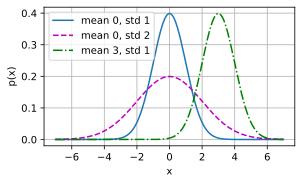

In [3]:
def normal(x, mu, sigma):
    p = (1 / math.sqrt(2 * math.pi * sigma ** 2)) * np.exp(-1/2 * 1 / sigma ** 2 * (x - mu) ** 2)
    return p

x = np.arange(-7, 7, 0.01)
params = [(0, 1), (0, 2), (3, 1)]

d2l.plot(x, [normal(x, mu, sigma) for mu, sigma in params], xlabel='x',
         ylabel='p(x)', figsize=(4.5, 2.5),
         legend=[f'mean {mu}, std {sigma}' for mu, sigma in params])

##### 似然
**似然**（likelihood）是一个概率分布函数，可以定义为
$L(\omega|X, y) = P(y|X, \omega)$

考虑正态分布下的似然，

$P(y \mid \mathbf{x}) = \frac{1}{\sqrt{2 \pi \sigma^2}} \exp\left(-\frac{1}{2 \sigma^2} (y - \mathbf{w}^\top \mathbf{x} - b)^2\right).$

其描述了根据模型可以预测的$\hat y$与真实的$y$的误差的概率分布；
我们更期待一个模型的似然函数更大，因为这通常意味着该模型更准确有效

#### 由线性回归看深度神经网络
生物学上的神经元可以接受多个输入信号，处理后输出一个信号到下一级。

类似地，可以把上述线性回归模型视为一个神经元：接受 $\mathbf{x}$ 作为输入，产生 $\hat y$ 作为输出。

在深度神经网络中，多个这样的神经元**分层排列**。前一层多个神经元的输出传入后一层，每层之间通常加入**非线性激活函数**（如 ReLU），否则多层线性叠加仍然等价于一个线性模型。

每个输入都与该层每个输出相连的结构称为**全连接层**（稠密层）。

## 线性回归的从零实现
尝试生成一个满足高斯噪声的数据集$\mathbf{y}= \mathbf{X} \mathbf{w} + b + \mathbf\epsilon.$，

其中$\mathbf{w} = [2, -3.4]^\top$、$b = 4.2$

features: tensor([ 0.4758, -1.0983]) 
labels: tensor([8.8884])


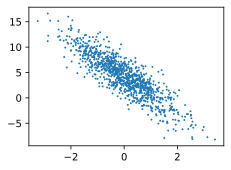

In [ ]:
import random

def synthetic_data(w, b, num_examples):
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

n = 0
print('features:', features[n], '\nlabels:', labels[n])

# 生成图查看样本情况
d2l.set_figsize()
d2l.plt.scatter(features[:, 1].detach().numpy(), labels.detach().numpy(), 1);

#### 读取数据集
需要产生一个函数在庞大的数据集中随机读取小批量样本以共随机梯度下降。

In [ ]:
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))

    random.shuffle(indices) # 把所有样本序号打乱
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(
            indices[i: min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]
    # 使用迭代器，一次返回一整批元素

调用如下

In [6]:
batch_size = 10

for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break

tensor([[ 1.6261,  1.9268],
        [-0.3210,  1.1268],
        [ 0.7520, -0.6901],
        [-0.0917, -0.8142],
        [-0.2142,  1.7313],
        [-0.1348,  0.2806],
        [-1.1264,  1.8306],
        [-1.3121,  0.4841],
        [ 0.0926,  0.3143],
        [-0.2983, -1.6761]]) 
 tensor([[ 0.8980],
        [-0.2650],
        [ 8.0556],
        [ 6.7786],
        [-2.1334],
        [ 2.9644],
        [-4.2776],
        [-0.0695],
        [ 3.2947],
        [ 9.2884]])


#### 初始化模型参数

In [ ]:
w = torch.normal(0, 0.01, size = (2, 1), requires_grad = True)
# 只是为了确保各个元素不相同

b = torch.zeros(1, requires_grad = True)

#### 定义模型


In [8]:
def linreg(X, w, b):
    '''线性回归模型'''
    return torch.matmul(X, w) + b #直接返回预测值hat y

#### 定义损失函数

In [ ]:
def squared_loss(y_hat, y):
    '''均方损失函数'''
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2 # 返回向量

#### 定义优化算法

In [ ]:
def sgd(params, lr, batch_size):
    '''小批量随机梯度下降'''
    with torch.no_grad():
        for param in params:                        # 遍历params里的所有量
            param -= lr * param.grad / batch_size   # 对里面的参数依次调整
            param.grad.zero_()                      # 重置梯度

#### 训练
训练的过程是一个循环：

1. 初始化参数
2. 循环训练直到训练完成
>a. 计算loss梯度
>b. 更新参数

In [ ]:
# 定义参数

# 超参
lr = 0.03       # 学习率
num_epochs = 3  # 迭代周期

# 重命名
net = linreg
loss = squared_loss

In [ ]:
#开始训练   
for epoch in range(num_epochs):         # 迭代num_epochs次
    for X, y in data_iter(batch_size, features, labels):    # 使用先前定义的迭代器选取一小部分样本
        l = loss(net(X, w, b), y)       # 定义损失函数
        l.sum().backward()              # 反向传播，考虑到l不是标量，因此先求和
        sgd([w, b], lr, batch_size)     # 更新参数
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)                     # 获取全样本集的loss
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')     # 输出测试
print(f'误差\nw: {true_w - w.reshape(true_w.shape)}\nb: {true_b - b}')

epoch 1, loss 0.032036
epoch 2, loss 0.000113
epoch 3, loss 0.000048
误差
w: tensor([-0.0010, -0.0001], grad_fn=<SubBackward0>)
b: tensor([0.0007], grad_fn=<RsubBackward1>)


## 基于框架的简单实现
#### 生成数据集
~~ (略，前文已实现)~~

#### 读取数据集

In [ ]:
from torch.utils import data

def load_array(data_arrays, batch_size, is_train = True):
    dataset = data.TensorDataset(*data_arrays)                          # 把元组解包成元素，xxx(a, b)
    return data.DataLoader(dataset, batch_size, shuffle = is_train)     # 返回的对象本质就是迭代器

batch_size = 10
data_iter = load_array((features, labels), batch_size)

print(next(iter(data_iter)))    # 检查迭代器

[tensor([[ 0.2056, -0.2365],
        [ 0.4600, -1.2657],
        [-0.2413, -0.3275],
        [ 0.4443,  0.9299],
        [ 1.1466,  0.6544],
        [ 0.9682,  0.9698],
        [ 0.8195,  1.2342],
        [-0.4908, -2.4061],
        [-0.9672, -0.2535],
        [-1.3931, -2.8706]]), tensor([[ 5.4122],
        [ 9.4357],
        [ 4.8219],
        [ 1.9350],
        [ 4.2795],
        [ 2.8468],
        [ 1.6420],
        [11.3948],
        [ 3.1282],
        [11.1731]])]


#### 定义模型
Pytorch提供多种预制模型，如即将使用的`nn.linear`。一般dl神经网络会使用Sequential类型串联多个层的计算，虽然对于线性模型这种单层模型不是必须的，但是使用Sequential更贴合未来的工程实践。

关于线性模型，每个输出都是由输入之间的矩阵乘法得出的，换言之每个输出需要调动所有输入，这种可称之为**全连接层**

In [ ]:
from torch import nn    # nn = Neural Network 神经网络

# 1. 创建模型
net = nn.Sequential(nn.Linear(2, 1))

# 2. 初始化模型参数
net[0].weight.data.normal_(0, 0.01)
net[0].